VGG 系列网络结构对比
VGG11    | 卷积层:  8 | 全连接层: 3 | 总参数量(卷积): 2,752
VGG13    | 卷积层: 10 | 全连接层: 3 | 总参数量(卷积): 2,944
VGG16    | 卷积层: 13 | 全连接层: 3 | 总参数量(卷积): 4,224
VGG19    | 卷积层: 16 | 全连接层: 3 | 总参数量(卷积): 5,504

VGG16 详细结构
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNo

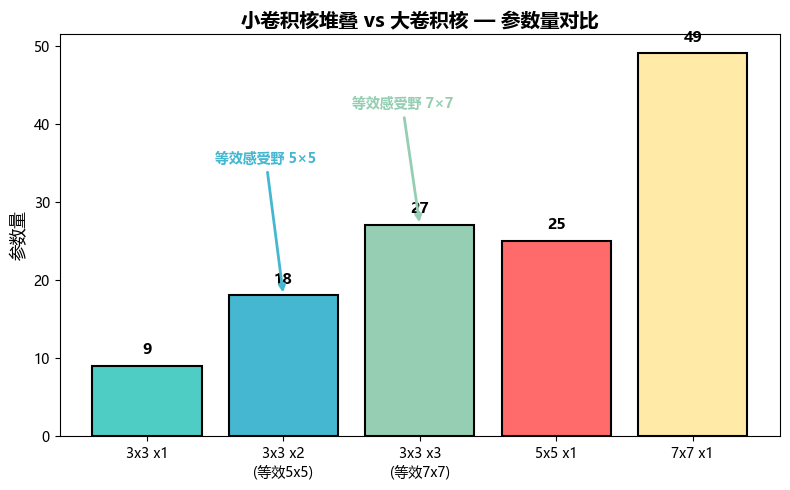


VGG16 前向传播 — 特征图尺寸变化 (输入 3×224×224)
层                    | 尺寸         | 通道    
------------------------------------------
 0. Conv 3→64        | 224×224    |     64
 3. Conv 64→64       | 224×224    |     64
 6. MaxPool2d        | 112×112    |     64
 7. Conv 64→128      | 112×112    |    128
10. Conv 128→128     | 112×112    |    128
13. MaxPool2d        | 56×56      |    128
14. Conv 128→256     | 56×56      |    256
17. Conv 256→256     | 56×56      |    256
20. Conv 256→256     | 56×56      |    256
23. MaxPool2d        | 28×28      |    256
24. Conv 256→512     | 28×28      |    512
27. Conv 512→512     | 28×28      |    512
30. Conv 512→512     | 28×28      |    512
33. MaxPool2d        | 14×14      |    512
34. Conv 512→512     | 14×14      |    512
37. Conv 512→512     | 14×14      |    512
40. Conv 512→512     | 14×14      |    512
43. MaxPool2d        | 7×7        |    512
               ... 全连接层 ...               

关键总结：
  - VGG 证明: 增加网络深度可以提升性能
  - 全部使用 3×3 小卷积核，堆叠加深网络
  -

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========== VGG 网络演示 ==========

# VGG 配置字典: (conv层数, 每层输出通道数)
# 'D' 对应 VGG16 (13个卷积层 + 3个全连接层)
vgg_cfgs = {
    'VGG11': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG13': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG16': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'],
    'VGG19': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M'],
}

def make_layers(cfg, in_channels=3):
    """根据配置构建 VGG 特征提取层"""
    layers = []
    for v in cfg:
        if v == 'M':
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            layers.append(nn.Conv2d(in_channels, v, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(v))
            layers.append(nn.ReLU(inplace=True))
            in_channels = v
    return nn.Sequential(*layers)

class VGG(nn.Module):
    """简易 VGG 实现 (不含分类头，便于观察特征提取结构)"""
    def __init__(self, name='VGG16', in_channels=3, num_classes=1000):
        super().__init__()
        cfg = vgg_cfgs[name]
        self.features = make_layers(cfg, in_channels)
        # 计算卷积 flattened 后的特征维度
        self._to_linear = None
        self._get_conv_output()
        self.classifier = nn.Sequential(
            nn.Linear(self._to_linear, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def _get_conv_output(self):
        """通过一次前向传播计算 flatten 后的维度"""
        dummy = torch.zeros(1, 3, 224, 224)
        out = self.features(dummy)
        self._to_linear = out.numel()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# ========== 1. 打印各 VGG 变体的结构信息 ==========
print("=" * 70)
print("VGG 系列网络结构对比")
print("=" * 70)

for name in ['VGG11', 'VGG13', 'VGG16', 'VGG19']:
    cfg = vgg_cfgs[name]
    conv_count = sum(1 for v in cfg if isinstance(v, int))
    fc_count = 3
    total_params = sum(v for v in cfg if isinstance(v, int))
    print(f"{name:8s} | 卷积层: {conv_count:2d} | 全连接层: {fc_count} | 总参数量(卷积): {total_params:>5,d}")
print()

# ========== 2. 实例化 VGG16 并观察结构 ==========
print("=" * 70)
print("VGG16 详细结构")
print("=" * 70)

vgg16 = VGG('VGG16')
print(vgg16)
print()

# 统计参数
total = sum(p.numel() for p in vgg16.parameters())
trainable = sum(p.numel() for p in vgg16.parameters() if p.requires_grad)
print(f"总参数量: {total:,d} ({total/1e6:.2f}M)")
print(f"可训练参数量: {trainable:,d} ({trainable/1e6:.2f}M)")
print()

# ========== 3. 可视化: 感受野与层数关系 (VGG 的核心思想: 小卷积核堆叠) ==========
print("=" * 70)
print("VGG 核心思想: 使用 3x3 小卷积核堆叠代替大卷积核")
print("=" * 70)

print("""
  堆叠 2 个 3x3 卷积  → 等效感受野 5x5  (参数量 2×3×3=18)
  堆叠 3 个 3x3 卷积  → 等效感受野 7x7  (参数量 3×3×3=27)
  一个 5x5 卷积       → 感受野 5x5      (参用量 5×5=25)
  一个 7x7 卷积       → 感受野 7x7      (参数量 7×7=49)

  ✅ 优势: 更少的参数量 + 更多的非线性激活 + 更深的网络
""")

# 可视化: 堆叠小卷积核 vs 单一大卷积核的参数量对比
fig, ax = plt.subplots(figsize=(8, 5))

kernels = ['3x3 x1', '3x3 x2\n(等效5x5)', '3x3 x3\n(等效7x7)', '5x5 x1', '7x7 x1']
params = [9, 18, 27, 25, 49]
colors = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FF6B6B', '#FFEAA7']

bars = ax.bar(kernels, params, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('参数量', fontsize=12)
ax.set_title('小卷积核堆叠 vs 大卷积核 — 参数量对比', fontsize=14, fontweight='bold')

# 在柱状图上标数值
for bar, p in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(p), ha='center', va='bottom', fontsize=11, fontweight='bold')

# 添加等效感受野标注
ax.annotate('等效感受野 5×5', xy=(1, 18), xytext=(0.5, 35),
            fontsize=10, color='#45B7D1', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#45B7D1', lw=2))
ax.annotate('等效感受野 7×7', xy=(2, 27), xytext=(1.5, 42),
            fontsize=10, color='#96CEB4', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#96CEB4', lw=2))

plt.tight_layout()
plt.show()

# ========== 4. VGG16 各层输出尺寸变化 ==========
print()
print("=" * 70)
print("VGG16 前向传播 — 特征图尺寸变化 (输入 3×224×224)")
print("=" * 70)

dummy = torch.randn(1, 3, 224, 224)
x = dummy
layer_names = []
hws = []
channels = []

for i, layer in enumerate(vgg16.features):
    x = layer(x)
    if isinstance(layer, (nn.Conv2d, nn.MaxPool2d)):
        _, c, h, w = x.shape
        name = layer.__class__.__name__
        if isinstance(layer, nn.Conv2d):
            name = f"Conv {layer.in_channels}→{layer.out_channels}"
        layer_names.append(f"{i:2d}. {name}")
        hws.append(f"{h}×{w}")
        channels.append(c)

# 打印表格
print(f"{'层':20s} | {'尺寸':10s} | {'通道':6s}")
print("-" * 42)
for ln, hw, ch in zip(layer_names, hws, channels):
    print(f"{ln:20s} | {hw:10s} | {ch:6d}")
print(f"{'... 全连接层 ...':^42s}")
print()

print("关键总结：")
print("  - VGG 证明: 增加网络深度可以提升性能")
print("  - 全部使用 3×3 小卷积核，堆叠加深网络")
print("  - VGG16/VGG19 是经典配置，迁移学习常用预训练模型")
print("  - 缺点: 参数量大 (~138M)，计算成本高")


# ResNet (Deep Residual Network)

## 背景
随着网络深度增加，传统网络会出现**退化问题（Degradation Problem）**— 不是过拟合，而是更深的网络反而训练误差和测试误差都更高。ResNet 通过**残差学习（Residual Learning）**解决了这一问题。

## 核心思想

### 残差块（Residual Block）
不再直接学习底层映射 $H(x)$，而是学习残差 $F(x) = H(x) - x$，再将输入 $x$ 加回：

$$H(x) = F(x) + x$$

这个 **"捷径连接"（Shortcut / Skip Connection）** 让梯度可以直达浅层，缓解梯度消失。

### 瓶颈结构（Bottleneck）
为减少计算量，深层 ResNet（50+）使用 1×1 卷积先降维再升维：

$$256\text{-d} \xrightarrow{1\times1, 64} \xrightarrow{3\times3, 64} \xrightarrow{1\times1, 256}$$

相比两个 3×3 卷积，参数量大幅减少。

## ResNet 系列
| 变体 | 层数 | 结构组件 |
|:---:|:---:|:---|
| ResNet-18 | 18 | 2 层残差块 ×4 组 |
| ResNet-34 | 34 | 3 层残差块 ×4 组 |
| ResNet-50 | 50 | 瓶颈块 ×4 组 |
| ResNet-101 | 101 | 瓶颈块 ×4 组（更多） |
| ResNet-152 | 152 | 瓶颈块 ×4 组（最多） |

## 关键贡献
- 残差学习让训练 100+ 层网络成为可能
- 批量归一化（BN）放在每个卷积之后
- 在 ImageNet 上达到 3.57% top-5 错误率（2015 年冠军）
- 极大影响后续网络设计（DenseNet、ResNeXt 等）


ResNet 系列参数量对比
ResNet-18    | 参数量: 11.69M
ResNet-34    | 参数量: 21.80M
ResNet-50    | 参数量: 25.56M
ResNet-101   | 参数量: 44.55M
ResNet-152   | 参数量: 60.19M

残差块结构对比

  BasicBlock (ResNet-18/34):
      ┌──────────────────────────────────┐
      │  Input (in_channels)             │
      │    ↓                             │
      │  Conv3×3 → BN → ReLU            │
      │    ↓                             │
      │  Conv3×3 → BN                   │
      │    ↓                    ┌─────── │
      │  (+) ←── Shortcut ←────┘        │
      │    ↓                             │
      │  ReLU → Output                   │
      └──────────────────────────────────┘

  Bottleneck (ResNet-50/101/152):
      ┌───────────────────────────────────────┐
      │  Input (256-d)                        │
      │    ↓                                  │
      │  Conv1×1, 64 → BN → ReLU  (降维)      │
      │    ↓                                  │
      │  Conv3×3, 64 → BN → ReLU             │
      │    ↓         

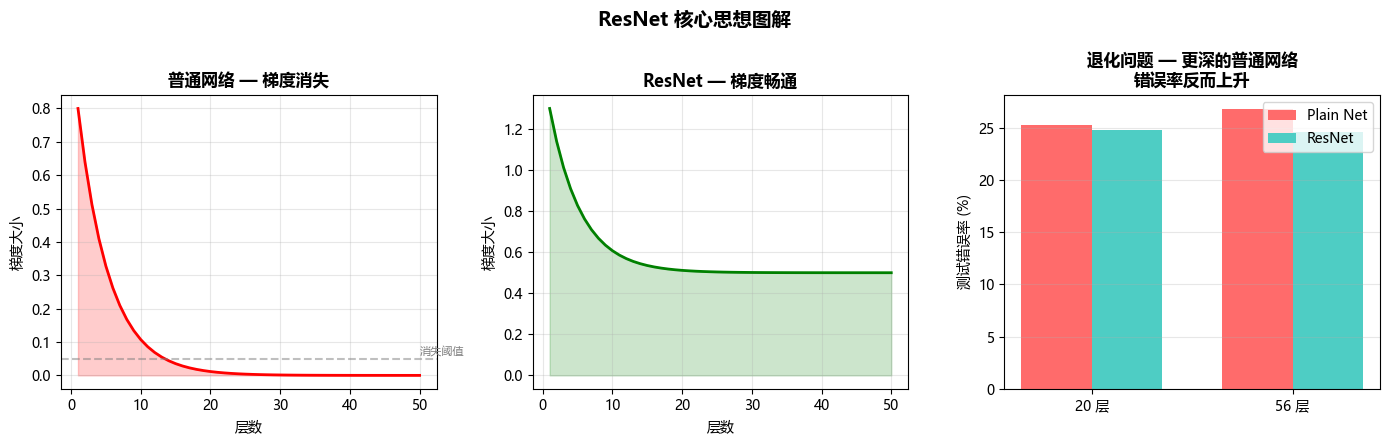

ResNet-18 特征图尺寸变化 (输入 3×224×224)
阶段           |     通道 |         尺寸
----------------------------------
Conv1        |     64 |  112×112 
Layer1       |     64 |   56×56  
Layer2       |    128 |   28×28  
Layer3       |    256 |   14×14  
Layer4       |    512 |    7×7   
AvgPool      |    512 |        1×1
FC           |   1000 |          -

关键总结：
  - 残差连接 F(x) + x 让梯度可以直达浅层
  - ResNet-18/34 使用 BasicBlock (两个 3×3)
  - ResNet-50/101/152 使用 Bottleneck (1×1 → 3×3 → 1×1)
  - 残差思想启发了后续 DenseNet、ResNeXt、Transformer 等架构
  - 即使 152 层也能稳定训练，参数量却比 VGG16 更少


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========== ResNet 核心组件实现 ==========

class BasicBlock(nn.Module):
    """基础残差块 (用于 ResNet-18/34)"""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 捷径连接：维度匹配时使用 1×1 卷积
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity  # 残差连接
        return F.relu(out)


class Bottleneck(nn.Module):
    """瓶颈残差块 (用于 ResNet-50/101/152)"""
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += identity
        return F.relu(out)


class ResNet(nn.Module):
    """通用 ResNet"""
    def __init__(self, block, num_blocks, num_classes=1000):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        self._initialize_weights()

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


def ResNet18(num_classes=1000):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

def ResNet34(num_classes=1000):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes)

def ResNet50(num_classes=1000):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes)

def ResNet101(num_classes=1000):
    return ResNet(Bottleneck, [3, 4, 23, 3], num_classes)

def ResNet152(num_classes=1000):
    return ResNet(Bottleneck, [3, 8, 36, 3], num_classes)


# ========== 1. 对比参数量 ==========
print("=" * 60)
print("ResNet 系列参数量对比")
print("=" * 60)

for name, builder in [('ResNet-18', ResNet18), ('ResNet-34', ResNet34),
                       ('ResNet-50', ResNet50), ('ResNet-101', ResNet101),
                       ('ResNet-152', ResNet152)]:
    net = builder(num_classes=1000)
    params = sum(p.numel() for p in net.parameters())
    print(f"{name:12s} | 参数量: {params/1e6:.2f}M")

print()

# ========== 2. 可视化：残差块结构对比 ==========
print("=" * 60)
print("残差块结构对比")
print("=" * 60)

print("""
  BasicBlock (ResNet-18/34):
      ┌──────────────────────────────────┐
      │  Input (in_channels)             │
      │    ↓                             │
      │  Conv3×3 → BN → ReLU            │
      │    ↓                             │
      │  Conv3×3 → BN                   │
      │    ↓                    ┌─────── │
      │  (+) ←── Shortcut ←────┘        │
      │    ↓                             │
      │  ReLU → Output                   │
      └──────────────────────────────────┘

  Bottleneck (ResNet-50/101/152):
      ┌───────────────────────────────────────┐
      │  Input (256-d)                        │
      │    ↓                                  │
      │  Conv1×1, 64 → BN → ReLU  (降维)      │
      │    ↓                                  │
      │  Conv3×3, 64 → BN → ReLU             │
      │    ↓                                  │
      │  Conv1×1, 256 → BN         (升维)     │
      │    ↓                         ┌──────  │
      │  (+) ←── Shortcut ←─────────┘        │
      │    ↓                                  │
      │  ReLU → Output (256-d)                │
      └───────────────────────────────────────┘
""")

# ========== 3. 可视化：残差连接 vs 普通网络 ==========
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# 左图：普通网络梯度消失
x_range = np.arange(1, 51)
plain_grad = 0.8 ** x_range  # 模拟梯度衰减
axes[0].plot(x_range, plain_grad, 'r-', linewidth=2)
axes[0].fill_between(x_range, 0, plain_grad, alpha=0.2, color='red')
axes[0].set_xlabel('层数')
axes[0].set_ylabel('梯度大小')
axes[0].set_title('普通网络 — 梯度消失', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0.05, color='gray', linestyle='--', alpha=0.5)
axes[0].text(50, 0.06, '消失阈值', fontsize=8, color='gray')

# 中图：残差网络梯度保持
res_grad = 0.8 ** x_range + 0.5  # 捷径连接保持梯度
axes[1].plot(x_range, res_grad, 'g-', linewidth=2)
axes[1].fill_between(x_range, 0, res_grad, alpha=0.2, color='green')
axes[1].set_xlabel('层数')
axes[1].set_ylabel('梯度大小')
axes[1].set_title('ResNet — 梯度畅通', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 右图：退化问题示意图
depth = [20, 56]
plain_err = [25.3, 26.8]   # CIFAR-10 上普通网络
res_err = [24.8, 24.6]      # ResNet
x = np.arange(len(depth))
width = 0.35
axes[2].bar(x - width/2, plain_err, width, label='Plain Net', color='#FF6B6B')
axes[2].bar(x + width/2, res_err, width, label='ResNet', color='#4ECDC4')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['20 层', '56 层'])
axes[2].set_ylabel('测试错误率 (%)')
axes[2].set_title('退化问题 — 更深的普通网络\n错误率反而上升', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('ResNet 核心思想图解', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ========== 4. ResNet18 前向传播尺寸变化 ==========
print("=" * 60)
print("ResNet-18 特征图尺寸变化 (输入 3×224×224)")
print("=" * 60)

net18 = ResNet18()
dummy = torch.randn(1, 3, 224, 224)
x = dummy
hooks_info = []

def hook_fn(name):
    def fn(module, input, output):
        _, c, h, w = output.shape
        hooks_info.append((name, c, h, w))
    return fn

# 注册钩子观察各层输出
layers_to_watch = [
    ('Conv1', net18.conv1),
    ('Layer1', net18.layer1),
    ('Layer2', net18.layer2),
    ('Layer3', net18.layer3),
    ('Layer4', net18.layer4),
]
handles = []
for name, layer in layers_to_watch:
    handles.append(layer.register_forward_hook(hook_fn(name)))

_ = net18(dummy)
for h in handles:
    h.remove()

print(f"{'阶段':12s} | {'通道':>6s} | {'尺寸':>10s}")
print("-" * 34)
for name, c, h, w in hooks_info:
    print(f"{name:12s} | {c:6d} | {h:4d}×{w:<4d}")
print(f"{'AvgPool':12s} | {'512':>6s} | {'1×1':>10s}")
print(f"{'FC':12s} | {'1000':>6s} | {'-':>10s}")

print()
print("关键总结：")
print("  - 残差连接 F(x) + x 让梯度可以直达浅层")
print("  - ResNet-18/34 使用 BasicBlock (两个 3×3)")
print("  - ResNet-50/101/152 使用 Bottleneck (1×1 → 3×3 → 1×1)")
print("  - 残差思想启发了后续 DenseNet、ResNeXt、Transformer 等架构")
print("  - 即使 152 层也能稳定训练，参数量却比 VGG16 更少")


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ========== ResNet-34 完整实现 ==========

class BasicBlock(nn.Module):
    """基础残差块 (用于 ResNet-18/34)"""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return F.relu(out)


class ResNet34(nn.Module):
    """ResNet-34"""
    def __init__(self, num_classes=1000):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        # ResNet-34: [3, 4, 6, 3] 个残差块
        self.layer1 = self._make_layer(64,  3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        self._initialize_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


# ========== 查看网络结构 ==========
print("=" * 65)
print("ResNet-34 完整结构")
print("=" * 65)

net = ResNet34(num_classes=1000)
print(net)

total_params = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params/1e6:.2f}M")
print(f"可训练参数量: {trainable_params/1e6:.2f}M")
print()

# ========== 特征图尺寸变化 ==========
print("=" * 65)
print("ResNet-34 前向传播 — 特征图尺寸变化 (输入 3×224×224)")
print("=" * 65)

dummy = torch.randn(1, 3, 224, 224)

# 注册钩子
shape_info = []
def make_hook(name):
    def hook(module, inp, out):
        shape_info.append((name, list(out.shape)))
    return hook

hooks = []
for name, mod in [('conv1', net.conv1), ('bn1/relu', net.bn1),
                   ('layer1', net.layer1), ('layer2', net.layer2),
                   ('layer3', net.layer3), ('layer4', net.layer4)]:
    hooks.append(mod.register_forward_hook(make_hook(name)))

_ = net(dummy)
for h in hooks:
    h.remove()

print(f"{'阶段':12s} | {'输出形状':>20s}")
print("-" * 36)
for name, shape in shape_info:
    print(f"{name:12s} | {str(shape):>20s}")
print(f"{'avgpool':12s} | {'[1, 512, 1, 1]':>20s}")
print(f"{'fc (输出)':12s} | {'[1, 1000]':>20s}")
print()

print("关键总结：")
print("  - ResNet-34: 34 层 (含 shortcut 不计入)")
print("  - 相比 ResNet-18 增加了 layer2~layer4 的残差块数量")
print("  - conv1 用 7×7 大卷积核快速降采样 (224→112→56)")
print("  - 通过 stride=2 的卷积下采样，无池化层")
print("  - 残差连接让 34 层也能稳定训练")

ResNet-34 完整结构
ResNet34(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3),